In [26]:
# Download the Python package for calling API Spotify
%pip install spotipy pandas networkx scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Set up the token for easy connnection of api
import requests
import base64
def get_access_token(client_id, client_secret):
    auth_url = 'https://accounts.spotify.com/api/token'
    auth_header = {
        'Authorization': f'Basic {base64.b64encode((client_id + ":" + client_secret).encode()).decode()}'
    }
    auth_data = {
        'grant_type': 'client_credentials',
        'client_id': client_id,
        'client_secret': client_secret
    }
    auth_response = requests.post(auth_url, data=auth_data, headers=auth_header)
    auth_response_data = auth_response.json()
    access_token = auth_response_data['access_token']
    return access_token

In [4]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# Set your credentials (Replace with your own)
client_id = "439571e5c8794498a9b662703559ceef"
client_secret = "07c140aa4cfa4730b10ece75805baa22"

client_credentials_manager = SpotifyClientCredentials(
    client_id=client_id,
    client_secret=client_secret,
)

# Authenticate API
sp = spotipy.Spotify(client_credentials_manager=client_credentials_manager)

access_token = get_access_token(client_id, client_secret)


In [ ]:
import pandas as pd
import time

# This is the version of asking user to input any artists' name and then it will sort out their albums and tracks 

def get_artist_id(artist_name): # Create a path to the name of artist
    result = sp.search(q=f'artist:{artist_name}', type='artist', limit=1)
    items = result['artists']['items']

    if not items:
        print(f"Artist '{artist_name}' not found.")
        return None
    return items[0]['id']

def get_unique_albums(artist_id): # Create a path to the ID attched with artist
    albums = sp.artist_albums(artist_id, album_type='album', limit=50)['items']

    seen = set()
    unique_albums = []
    for album in albums:
        album_name = album['name'].lower()
        if album_name not in seen:
            unique_albums.append(album)
            seen.add(album_name)
    return unique_albums

def create_full_album_dataframe(artist_name): # Create the structure of album retrieval
    data = {
        'Track ID': [],
        'Track name': [],
        'Artist': [],
        'Popularity score': [],
        'Release': [],
        'Album': []
    }

    artist_id = get_artist_id(artist_name) # Link with the function "get_artist_id"
    if not artist_id:
        return pd.DataFrame()

    unique_albums = get_unique_albums(artist_id) # Link with the function "get_unique_albums"

    for album in unique_albums: # Create a loop for each album retrieval from the artist call
        album_id = album['id']
        album_title = album['name']
        album_release_year = album['release_date'][:4] # It is year release

        try: # To set the error management when executing is wrong
            tracks = sp.album_tracks(album_id)['items']
        except Exception as e:
            print(f"Error fetching tracks for album {album_title}: {e}")
            continue

        for track in tracks: # Also every track is called in each album
            track_id = track['id']
            track_name = track['name']
            try:
                popularity = sp.track(track_id)['popularity']
            except Exception:
                popularity = None

            data['Track ID'].append(track_id)
            data['Track name'].append(track_name)
            data['Artist'].append(artist_name)
            data['Popularity score'].append(popularity)
            data['Release'].append(album_release_year)
            data['Album'].append(f"{album_title}")

            time.sleep(0.1) # Avoid send dozens or hunderds of rapid API calls after each track
        time.sleep(1) # Avoid send dozens or hunderds of rapid API calls after each album

    return pd.DataFrame(data)

# Call the function to ask for the name of artist
artist_input = input("Enter the name of the artist: ")
df = create_full_album_dataframe(artist_input)
df

,Track ID,Track name,Artist,Popularity score,Release,Album
0,5LYMamLv12UPbemOaTPyeV,Music For a Sushi Restaurant,Harry Styles,73,2022,Harry's House
1,1qEmFfgcLObUfQm0j1W2CK,Late Night Talking,Harry Styles,79,2022,Harry's House
2,4j6kId9QIqhoXvqHKgSKa0,Grapejuice,Harry Styles,69,2022,Harry's House
3,4Dvkj6JhhA12EX05fT7y2e,As It Was,Harry Styles,89,2022,Harry's House
4,51Zw1cKDgkad0CXv23HCMU,Daylight,Harry Styles,72,2022,Harry's House
5,3i058E8uxTsYqJ5NWZzqSj,Little Freak,Harry Styles,74,2022,Harry's House
6,6uvh0In7u1Xn4HgxOfAn8O,Matilda,Harry Styles,79,2022,Harry's House
7,35TyJIMR3xRouUuo2sjS6v,Cinema,Harry Styles,70,2022,Harry's House
8,69w5X6uTrOaWM32IetSzvO,Daydreaming,Harry Styles,69,2022,Harry's House
9,2NcQic8JxdjAlAHuNbOIRE,Keep Driving,Harry Styles,72,2022,Harry's House


In [5]:
import pandas as pd
import time

def get_album_id(artist_name, target_album):
    # Search for the artist
    result = sp.search(q=f'artist:{artist_name}', type='artist', limit=1)
    artist_items = result['artists']['items']
    if not artist_items:
        print(f"Artist '{artist_name}' not found.")
        return None

    artist_id = artist_items[0]['id']

    # Get albums of the artist
    albums = sp.artist_albums(artist_id, album_type='album')['items']
    
    # Remove duplicates by album name (Spotify sometimes returns many duplicates)
    seen = set()
    unique_albums = []
    for album in albums:
        if album['name'] not in seen:
            unique_albums.append(album)
            seen.add(album['name'])

    # Find the correct album by title
    for album in unique_albums:
        if album['name'].lower() == target_album.lower():
            return album  # return full album object

    print(f"Album '{target_album}' not found for artist '{artist_name}'")
    return None

def create_album_dataframe(artist_name, album_titles):
    data = {
        'Track ID': [],
        'Track name': [],
        'Artist': [],
        'Popularity score': [],
        'Release date': [],
        'Album': []
    }

    for title in album_titles:
        album = get_album_id(artist_name, title)
        if not album:
            continue

        album_id = album['id']
        album_release_date = album['release_date'][:4]
        album_title = album['name']
        
        tracks = sp.album_tracks(album_id)['items']

        for track in tracks:
            track_info = sp.track(track['id'])  # get popularity
            data['Track ID'].append(track['id'])
            data['Track name'].append(track['name'])
            data['Artist'].append(artist_name)
            data['Popularity score'].append(track_info['popularity'])
            data['Release date'].append(album_release_date)
            data['Album'].append(f"{album_title}")
            time.sleep(0.1)  # prevent rate-limiting

        time.sleep(1)

    df = pd.DataFrame(data)
    return df

# Use correct titles exactly as Spotify uses them
artist = "Harry Styles"
albums = ["Harry Styles", "Fine Line", "Harry's House"]

df = create_album_dataframe(artist, albums)
df


,Track ID,Track name,Artist,Popularity score,Release date,Album
0,4u9Y4Z9i9VaAbBK7rW1Rha,Meet Me in the Hallway,Harry Styles,65,2017,Harry Styles
1,5Ohxk2dO5COHF1krpoPigN,Sign of the Times,Harry Styles,87,2017,Harry Styles
2,3Dwq1oiOFys6Sxr5SslmXw,Carolina,Harry Styles,66,2017,Harry Styles
3,4B1rpPmQXwj78wk6aIGwwU,Two Ghosts,Harry Styles,69,2017,Harry Styles
4,5kRPPEWFJIMox5qIkQkiz5,Sweet Creature,Harry Styles,73,2017,Harry Styles
5,5Lbsc65org0b85kNsPkluY,Only Angel,Harry Styles,66,2017,Harry Styles
6,33SNO8AaciGbNaQFkxvPrW,Kiwi,Harry Styles,72,2017,Harry Styles
7,5LABCxgmP7DATATIJXOh6n,Ever Since New York,Harry Styles,65,2017,Harry Styles
8,33bURv895AN4FkBvgFo2dx,Woman,Harry Styles,66,2017,Harry Styles
9,1IF5UcqRO42D12vYwceOY6,From the Dining Table,Harry Styles,70,2017,Harry Styles


In [ ]:
df['Album'].value_counts() # Count how many tracks are in each album

Album
Harry's House    13
Fine Line        12
Harry Styles     10
Name: count, dtype: int64

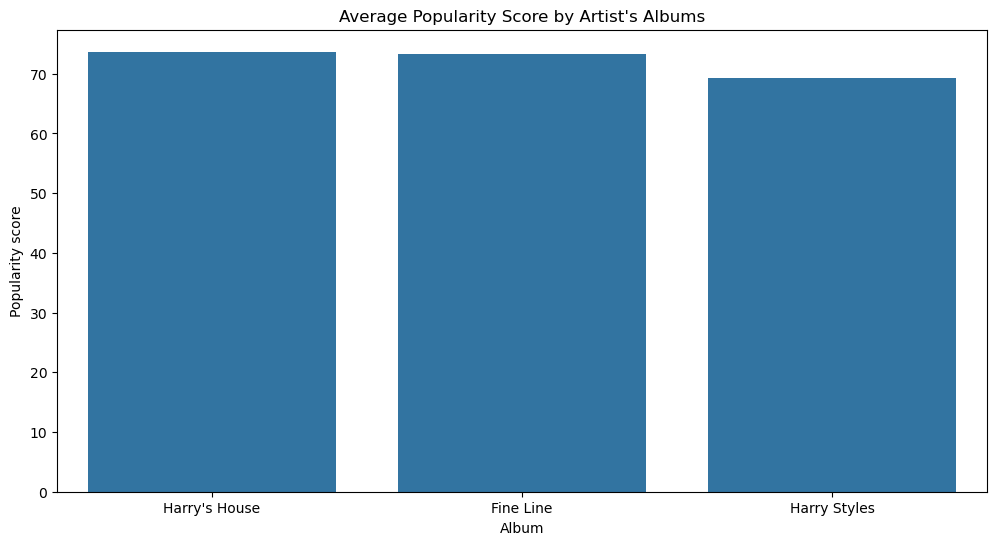

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average popularity score for each album
album_popularity = df.groupby('Album')['Popularity score'].mean().reset_index()

# Sort the albums by average popularity score in descending order
album_popularity = album_popularity.sort_values('Popularity score', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Album', y='Popularity score', data=album_popularity)
plt.xticks()
plt.title("Average Popularity Score by Artist's Albums")
plt.show()


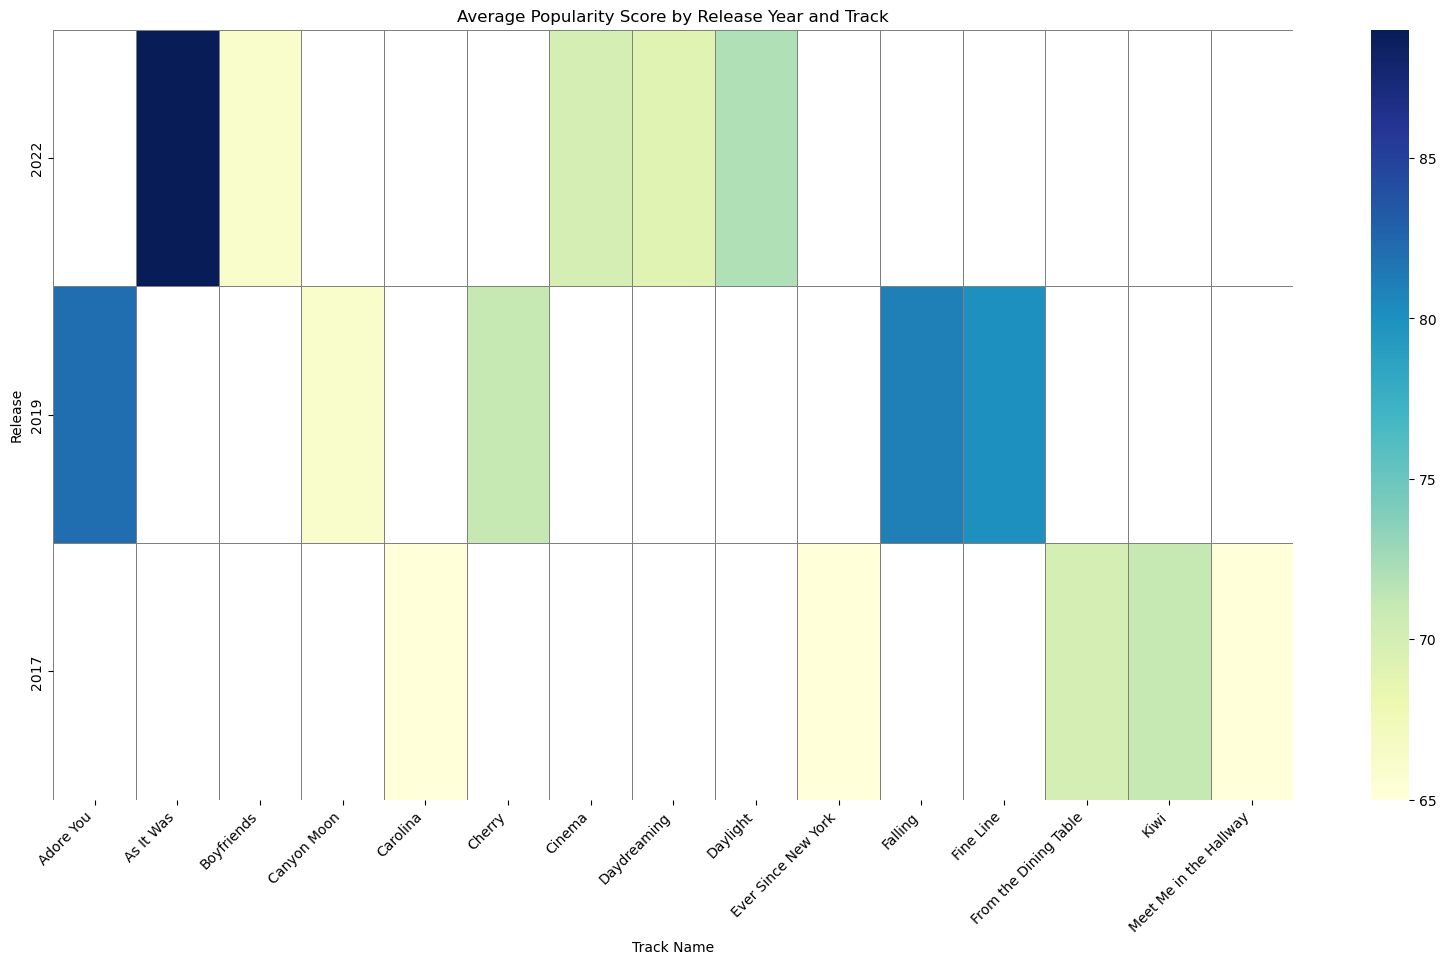

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

first_5_tracks_df = df.sort_values(by=['Album', 'Track name']).groupby('Album').head(5)

# Create pivot table: rows = year, columns = track, values = avg popularity
heatmap_data = first_5_tracks_df.pivot_table(index='Release date', columns='Track name', values='Popularity score', aggfunc='mean').sort_values('Release date', ascending=False)


# Plot heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, fmt=".1f", linewidths=0.5, linecolor='gray')
plt.title("Average Popularity Score by Release Year and Track")
plt.xlabel("Track Name")
plt.ylabel("Release")
plt.xticks(rotation=45, ha='right')
plt.show()

# End project


